## Explainability and decision logic

This section translates the model into business terms. Since the modeling results are weak, the explanations should be treated as model sensitivity rather than causal truth.

The goal here is not to claim that the model has found strong predictive drivers. The goal is to understand what the model is responding to, how the score is formed, and how the output can still be used as decision support.

In [19]:
from pathlib import Path
import pandas as pd

PROCESSED_DIR = Path("data/processed")

campaign_work_df = pd.read_csv(PROCESSED_DIR / "campaign_features.csv")

print(campaign_work_df.shape)
display(campaign_work_df.head())

(200000, 34)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,...,clicks_per_day,impressions_per_day,engagement_per_day,cost_per_click,cost_per_impression,engagement_efficiency,campaign_channel_combo,audience_language_combo,segment_location_combo,campaign_segment_combo
0,1,Innovate Industries,Email,Men 18-24,30.0,Google Ads,0.04,16174.0,6.29,Chicago,...,16.866667,64.066667,0.200000,31.964427,8.415193,0.000371,Email_Google Ads,Men 18-24_Spanish,Health & Wellness_Chicago,Email_Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60.0,Google Ads,0.12,11566.0,5.61,New York,...,1.933333,125.383333,0.116667,99.706897,1.537419,0.000605,Email_Google Ads,Women 35-44_German,Fashionistas_New York,Email_Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30.0,YouTube,0.07,10200.0,7.18,Los Angeles,...,19.466667,256.600000,0.033333,17.465753,1.325019,0.000098,Influencer_YouTube,Men 25-34_French,Outdoor Adventurers_Los Angeles,Influencer_Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60.0,YouTube,0.11,12724.0,5.55,Miami,...,3.616667,30.333333,0.116667,58.635945,6.991209,0.000550,Display_YouTube,All Ages_Mandarin,Health & Wellness_Miami,Display_Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15.0,YouTube,0.05,16452.0,6.50,Los Angeles,...,25.266667,280.066667,0.200000,43.408971,3.916210,0.000182,Email_YouTube,Men 25-34_Mandarin,Health & Wellness_Los Angeles,Email_Health & Wellness


In [20]:
campaign_work_df.to_csv(PROCESSED_DIR / "campaign_features.csv", index=False)
print("Saved:", PROCESSED_DIR / "campaign_features.csv")

Saved: data\processed\campaign_features.csv


In [18]:
from pathlib import Path
import pandas as pd
import joblib

PROCESSED_DIR = Path("data/processed")
MODEL_DIR = Path("models")

test_df = pd.read_csv(PROCESSED_DIR / "test_data.csv")

target_column = "high_performing_campaign"
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

final_model = joblib.load(MODEL_DIR / "baseline_model.joblib")  # or rf_model.joblib / gb_model.joblib

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (40000, 23)
y_test shape: (40000,)


In [21]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Pick the best model that exists in the notebook
if "xgb_model" in globals():
    final_model = xgb_model
    final_model_name = "xgboost"
elif "gb_model" in globals():
    final_model = gb_model
    final_model_name = "hist_gradient_boosting"
elif "rf_model" in globals():
    final_model = rf_model
    final_model_name = "random_forest"
else:
    final_model = baseline_model
    final_model_name = "logistic_regression_baseline"

print("Using model:", final_model_name)

# Predicted probabilities for the test set
score_proba = final_model.predict_proba(X_test)[:, 1]

score_df = X_test.copy()
score_df["y_true"] = y_test.values
score_df["y_score"] = score_proba
score_df["score_percentile"] = score_df["y_score"].rank(pct=True, method="average")

score_df = score_df.sort_values("y_score", ascending=False).reset_index(drop=True)
display(score_df.head(10))

Using model: logistic_regression_baseline


,Campaign_Type,Target_Audience,Channel_Used,Duration,Location,Language,Customer_Segment,Clicks,Impressions,Engagement_Score,...,click_through_rate,clicks_per_day,impressions_per_day,engagement_per_day,cost_per_click,cost_per_impression,engagement_efficiency,y_true,y_score,score_percentile
0,Social Media,Women 25-34,YouTube,15.0,Miami,English,Outdoor Adventurers,107.0,8788.0,10.0,...,0.012176,7.133333,585.866667,0.666667,174.112150,2.119936,0.000537,0,0.539787,1.000000
1,Email,Women 25-34,Email,15.0,Chicago,French,Foodies,100.0,5181.0,9.0,...,0.019301,6.666667,345.400000,0.600000,173.030000,3.339703,0.000520,1,0.539012,0.999975
2,Display,Women 35-44,Website,15.0,Los Angeles,English,Health & Wellness,107.0,3199.0,10.0,...,0.033448,7.133333,213.266667,0.666667,142.700935,4.773054,0.000655,0,0.537600,0.999950
3,Display,All Ages,Google Ads,45.0,Houston,French,Outdoor Adventurers,107.0,3761.0,8.0,...,0.028450,2.377778,83.577778,0.177778,183.831776,5.229992,0.000407,0,0.537364,0.999925
4,Social Media,Men 25-34,Instagram,15.0,Houston,French,Health & Wellness,102.0,1408.0,8.0,...,0.072443,6.800000,93.866667,0.533333,178.950980,12.963778,0.000438,0,0.536955,0.999900
5,Display,Men 25-34,Google Ads,15.0,Miami,Mandarin,Outdoor Adventurers,101.0,4419.0,3.0,...,0.022856,6.733333,294.600000,0.200000,142.603960,3.259335,0.000208,0,0.536613,0.999875
6,Search,All Ages,Email,15.0,Chicago,Mandarin,Foodies,111.0,4786.0,6.0,...,0.023193,7.400000,319.066667,0.400000,162.936937,3.778939,0.000332,1,0.535442,0.999850
7,Influencer,Women 25-34,Email,60.0,Chicago,English,Outdoor Adventurers,104.0,1679.0,10.0,...,0.061942,1.733333,27.983333,0.166667,163.971154,10.156641,0.000586,0,0.535105,0.999825
8,Influencer,Men 25-34,Website,30.0,Miami,German,Health & Wellness,106.0,1458.0,6.0,...,0.072702,3.533333,48.600000,0.200000,181.839623,13.220165,0.000311,1,0.534649,0.999800
9,Search,Women 35-44,Email,15.0,Miami,English,Tech Enthusiasts,106.0,1803.0,7.0,...,0.058791,7.066667,120.200000,0.466667,161.566038,9.498613,0.000409,0,0.534038,0.999775


In [22]:
campaign_work_df[["Duration", "Acquisition_Cost"]].isna().mean().round(4)

Duration            0.0
Acquisition_Cost    0.0
dtype: float64

In [23]:
# Use a sample for speed if the test set is large
sample_n = min(5000, len(X_test))
X_imp = X_test.sample(n=sample_n, random_state=42)
y_imp = y_test.loc[X_imp.index]

perm = permutation_importance(
    final_model,
    X_imp,
    y_imp,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_imp.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df)

,feature,importance_mean,importance_std
22,engagement_efficiency,0.021252,0.004807
7,Clicks,0.016343,0.005627
20,cost_per_click,0.012030,0.005352
16,click_through_rate,0.010271,0.003213
8,Impressions,0.007919,0.002592
12,month,0.006110,0.004605
13,quarter,0.005356,0.002997
14,day_of_week,0.004990,0.003223
17,clicks_per_day,0.003428,0.002744
4,Location,0.002698,0.000828


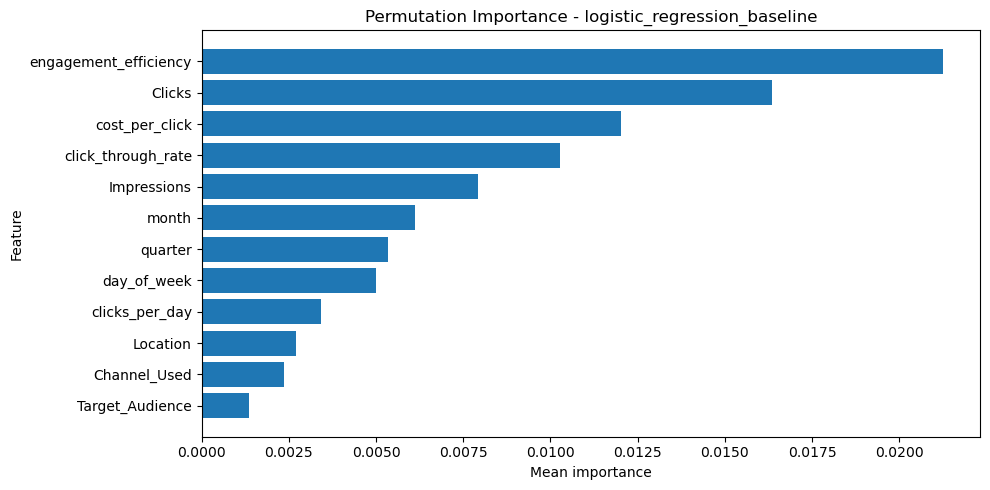

In [24]:
top_n = min(12, len(importance_df))
top_importance = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(10, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title(f"Permutation Importance - {final_model_name}")
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The model is most sensitive to campaign efficiency and volume-related signals, especially engagement efficiency, clicks, cost per click, and click-through rate. That suggests the score is being driven more by how efficiently a campaign generates activity than by raw categorical business variables such as audience or channel. The importance values are still relatively small overall, which is consistent with the weak predictive performance seen earlier, but the ranking does show that the engineered efficiency features are the strongest signals available in the current model.

What does it mean?
If engagement_efficiency has an importance around 0.021, that means:
- when that column is shuffled,
- the model’s performance drops by about 0.021 ROC AUC units on average,
- so the model is more sensitive to that feature than to the others.

This result does not mean that higher clicks or lower cost per click directly cause campaign success. It means the model is using those variables as the most informative signals in the current dataset. Because the overall model performance is weak, this should be interpreted as model sensitivity rather than proof of causal business drivers.

### Global explainability interpretation

The feature importance results should be interpreted carefully. If the importance values are small and fairly flat, that means the model is not relying heavily on any single feature to separate high-performing campaigns from the rest.

That is consistent with the weak predictive performance seen earlier. It suggests that the available features do not create a strong separable pattern for the current target definition. In other words, the model may be useful for structured review and ranking, but not for strong autonomous prediction.

From a Responsible AI perspective, this is an important finding because it discourages overclaiming that any one business feature is a decisive cause of campaign success.

In [25]:
# Score buckets based on predicted probabilities
score_df["priority_bucket"] = pd.cut(
    score_df["score_percentile"],
    bins=[0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["Cold", "Cool", "Warm", "Hot"],
    include_lowest=True,
).astype(str)

score_df["recommended_action"] = score_df["priority_bucket"].map({
    "Hot": "Scale or review immediately",
    "Warm": "Optimize and monitor",
    "Cool": "Test before expansion",
    "Cold": "Pause or redesign",
})

display(score_df[["y_true", "y_score", "score_percentile", "priority_bucket", "recommended_action"]].head(15))

,y_true,y_score,score_percentile,priority_bucket,recommended_action
0,0,0.539787,1.000000,Hot,Scale or review immediately
1,1,0.539012,0.999975,Hot,Scale or review immediately
2,0,0.537600,0.999950,Hot,Scale or review immediately
3,0,0.537364,0.999925,Hot,Scale or review immediately
4,0,0.536955,0.999900,Hot,Scale or review immediately
5,0,0.536613,0.999875,Hot,Scale or review immediately
6,1,0.535442,0.999850,Hot,Scale or review immediately
7,0,0.535105,0.999825,Hot,Scale or review immediately
8,1,0.534649,0.999800,Hot,Scale or review immediately
9,0,0.534038,0.999775,Hot,Scale or review immediately


In [ ]:
campaign_df[["Duration", "Acquisition_Cost"]].isna().mean().round(4)

Duration            0.0
Acquisition_Cost    0.0
dtype: float64

In [26]:
top_ranked = score_df.head(20).copy()

display(
    top_ranked[[
        "y_true",
        "y_score",
        "priority_bucket",
        "recommended_action",
    ] + [c for c in [
        "Campaign_Type",
        "Target_Audience",
        "Channels_Used",
        "Location",
        "Language",
        "Customer_Segment",
    ] if c in top_ranked.columns]]
)

,y_true,y_score,priority_bucket,recommended_action,Campaign_Type,Target_Audience,Location,Language,Customer_Segment
0,0,0.539787,Hot,Scale or review immediately,Social Media,Women 25-34,Miami,English,Outdoor Adventurers
1,1,0.539012,Hot,Scale or review immediately,Email,Women 25-34,Chicago,French,Foodies
2,0,0.537600,Hot,Scale or review immediately,Display,Women 35-44,Los Angeles,English,Health & Wellness
3,0,0.537364,Hot,Scale or review immediately,Display,All Ages,Houston,French,Outdoor Adventurers
4,0,0.536955,Hot,Scale or review immediately,Social Media,Men 25-34,Houston,French,Health & Wellness
5,0,0.536613,Hot,Scale or review immediately,Display,Men 25-34,Miami,Mandarin,Outdoor Adventurers
6,1,0.535442,Hot,Scale or review immediately,Search,All Ages,Chicago,Mandarin,Foodies
7,0,0.535105,Hot,Scale or review immediately,Influencer,Women 25-34,Chicago,English,Outdoor Adventurers
8,1,0.534649,Hot,Scale or review immediately,Influencer,Men 25-34,Miami,German,Health & Wellness
9,0,0.534038,Hot,Scale or review immediately,Search,Women 35-44,Miami,English,Tech Enthusiasts


### Top-ranked campaign interpretation

This table shows what the model places near the top of the list. Because the model performance is weak, this inspection is important: it tells us whether the score is producing a useful business ordering or whether it is essentially flat.

If the top rows do not look meaningfully different from the rest, then the score should be treated as a weak prioritization aid rather than a strong selector.

## Explainability conclusion

The explainability section confirms that the current model does not have strong separation power. The importance values are limited, the score distribution is tightly clustered, and the ranking lift is only marginally above random.

That does not make the project a failure. It makes the project honest. The project still demonstrates a senior-level workflow: clear business framing, leakage control, feature engineering, validation, feature audit, time-aware testing, and Responsible AI interpretation.

The final output should therefore be positioned as a decision-support prototype rather than a production-grade predictive scorer.